## Project 1 results

From the project 1 we obtained best results for ADAM_Ridge model degree 7,  lambda 0.0 and learning rate 0.1

test_mse: 0.014318

Compare these results with your neural network with one and two hidden layers using 50 and 100 hidden nodes, respectively.

Make an analysis of the learning rates employed to find the optimal MSE score. 

Test both stochastic gradient descent with RMSprop and ADAM and plain gradient descent with different learning rates.

The grid search is done with help of chat GPT

In [22]:
import warnings
import autograd.numpy as np  
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

from functions import (
    cost,create_layers_batch,  feed_forward_batch, feed_forward_saver_batch,
    backpropagation_batch, polynomial_features, plot_accuracy, plot_MSE_to_Iter, print_output, calculate_nlayer_nn
)
from activations import (
    sigmoid, ReLU, leaky_ReLu, sigmoid_der, ReLU_der, leaky_ReLU_der, softmax, softmax_der
)
from costs import (
    mse, mse_der, cross_entropy, binary_cross_entropy_loss,
    binary_cross_entropy_loss_l1, binary_cross_entropy_loss_l2,
    multiclass_cross_entropy_loss, crossentropy_der
)
from train_funct import (
    train_network, train_network_SGD_momentum, train_network_RMSprop, train_network_ADAM
)  

# Single run

In [2]:
# Setting seed for reproducibility
np.random.seed(42)
n = 200

# Creating a grid of n=200 points drawn from the random distribution
x = np.random.uniform(-1, 1, n)

# Setting up Runge's function, 1 normal and 1 with added noise
y = 1.0 / (1 + 25 * x**2) + np.random.normal(0, 0.1, x.shape)

# Calculating sample statistics
x_mean = np.mean(x)
x_variance = np.std(x, ddof=1) #sample variance

#Scaling x values for a visual comparison
x_st = (x - x_mean) / x_variance

# Now we split the dataset for training and testing (using the standardized x values) and noisy Runge
X_train, X_test, y_train, y_test = train_test_split(x_st, y, test_size=0.2, random_state = 42)


In [3]:
def plot_MSE(mse_total):
    n_iter = [point[0] for point in mse_total]
    mse_vals = [point[1] for point in mse_total]
    plt.figure(figsize=(12, 6))
    plt.plot(n_iter, mse_vals, marker='o')
    plt.title('Numbers of iterations to MSE value, SGD', fontsize=30)
    plt.xlabel('Number of Iterations', fontsize=25)
    plt.ylabel('MSE', fontsize=25)
    plt.yscale('log')
    plt.grid(True)
    plt.show()

initial prediction mse:  7.270904429351461
train MSE:  0.06100621307830195
test MSE:  0.07234581411106461


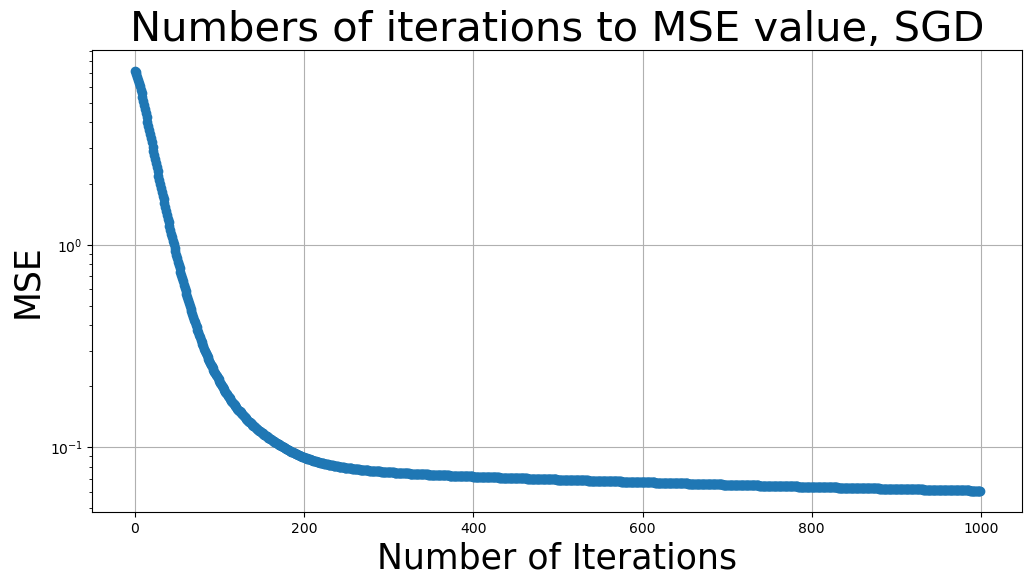

In [4]:
# Define NN parameter
poly_degree = 7
inputs_train = np.array(polynomial_features(X_train, poly_degree))
targets_train = y_train.reshape(-1, 1)

inputs_test = np.array(polynomial_features(X_test, poly_degree))
targets_test = y_test.reshape(-1, 1)
#print('target', targets)
n_iter = 1000


lern_rate = 0.01
network_input_size = poly_degree + 1
layer_output_sizes = [100, 100,1]
activation_funcs = [ sigmoid,sigmoid, ReLU]
activation_ders = [ sigmoid_der,sigmoid_der, ReLU_der]

#test that predict changes
layers = create_layers_batch(network_input_size, layer_output_sizes)
init_predictions = feed_forward_batch(inputs_train, layers, activation_funcs)
print('initial prediction mse: ', mse(init_predictions, targets_train))

# train network: can choose type of gradient there
predictions, last_prediction, layers_appended = train_network_SGD_momentum(inputs_train, layers, activation_funcs, targets_train, activation_ders, learning_rate=lern_rate, epochs=n_iter)
print('train MSE: ',mse(targets_train,last_prediction))

test_predict = feed_forward_batch(inputs_test, layers_appended, activation_funcs)
print('test MSE: ',mse(test_predict,targets_test))


mse_total = []
for i in range(n_iter):
    mse_temp = mse(predictions[i], targets_train)
    mse_total.append([i,mse_temp])

plot_MSE(mse_total)

In [5]:
# ---- Grid over learning rates ----
poly_degree = 7
inputs_train = np.array(polynomial_features(X_train, poly_degree))
targets_train = y_train.reshape(-1, 1)

inputs_test = np.array(polynomial_features(X_test, poly_degree))
targets_test = y_test.reshape(-1, 1)

network_input_size = poly_degree + 1

# Gradient discend

## 1 layer

In [6]:
results, histories = calculate_nlayer_nn(
    inputs_train = inputs_train, 
    targets_train = targets_train,
    inputs_test = inputs_test, 
    targets_test = targets_test, 
    n_iter=1000,
    learning_rates = [1e-4, 1e-3, 1e-2, 1e-1],
    network_input_size = network_input_size,
    layer_output_sizes=[50, 1],
    activation_funcs=[sigmoid, ReLU],
    activation_ders=[sigmoid_der, ReLU_der],
    train_network_type = train_network)
print_output(results, gd_type = 'GD')


=== Learning rate summary GD ===
lr=0.0001    train MSE=0.778385  test MSE=0.748893
lr=0.001     train MSE=0.696017  test MSE=0.663211
lr=0.01      train MSE=0.288235  test MSE=0.243242
lr=0.1       train MSE=0.159851  test MSE=0.115144


## 2 layers

In [7]:
results, histories = calculate_nlayer_nn(
    inputs_train = inputs_train, 
    targets_train = targets_train,
    inputs_test = inputs_test, 
    targets_test = targets_test, 
    n_iter=1000,
    learning_rates = [1e-4, 1e-3, 1e-2, 1e-1],
    network_input_size = network_input_size,
    layer_output_sizes=[100,100, 1],
    activation_funcs=[sigmoid,sigmoid, ReLU],
    activation_ders=[sigmoid_der,sigmoid_der, ReLU_der],
    train_network_type = train_network)
print_output(results, gd_type = 'GD')


=== Learning rate summary GD ===
lr=0.0001    train MSE=6.621147  test MSE=7.084277
lr=0.001     train MSE=2.983259  test MSE=3.332193
lr=0.01      train MSE=0.093537  test MSE=0.127502
lr=0.1       train MSE=0.052726  test MSE=0.064122


## SGD_momentum

In [8]:
# 1 layer

In [9]:
results, histories = calculate_nlayer_nn(
    inputs_train = inputs_train, 
    targets_train = targets_train,
    inputs_test = inputs_test, 
    targets_test = targets_test, 
    n_iter=1000,
    learning_rates = [1e-4, 1e-3, 1e-2, 1e-1],
    network_input_size = network_input_size,
    layer_output_sizes=[50, 1],
    activation_funcs=[sigmoid, ReLU],
    activation_ders=[sigmoid_der, ReLU_der],
    train_network_type = train_network_SGD_momentum)
print_output(results, gd_type = 'SGD')

#title_text = 'MSE to n iterations, SGD \n for different learning rates'
#plot_MSE_to_Iter(title_text,histories)


=== Learning rate summary SGD ===
lr=0.0001    train MSE=0.740482  test MSE=0.709457
lr=0.001     train MSE=0.445243  test MSE=0.403328
lr=0.01      train MSE=0.160210  test MSE=0.115802
lr=0.1       train MSE=0.159411  test MSE=0.114675


In [10]:
## 2 layers

In [11]:
results, histories = calculate_nlayer_nn(
    inputs_train = inputs_train, 
    targets_train = targets_train,
    inputs_test = inputs_test, 
    targets_test = targets_test, 
    n_iter=1000,
    learning_rates = [1e-4, 1e-3, 1e-2, 1e-1],
    network_input_size = network_input_size,
    layer_output_sizes=[100,100, 1],
    activation_funcs=[sigmoid,sigmoid, ReLU],
    activation_ders=[sigmoid_der,sigmoid_der, ReLU_der],
    train_network_type = train_network_SGD_momentum)
print_output(results, gd_type = 'GD')


=== Learning rate summary GD ===
lr=0.0001    train MSE=4.610538  test MSE=5.013983
lr=0.001     train MSE=0.237519  test MSE=0.352277
lr=0.01      train MSE=0.061006  test MSE=0.072346
lr=0.1       train MSE=0.019659  test MSE=0.030396


# RMSprop

In [12]:
# 1 layer

In [13]:
results, histories = calculate_nlayer_nn(
    inputs_train = inputs_train, 
    targets_train = targets_train,
    inputs_test = inputs_test, 
    targets_test = targets_test, 
    n_iter=1000,
    learning_rates = [1e-4, 1e-3, 1e-2, 1e-1],
    network_input_size = network_input_size,
    layer_output_sizes=[50, 1],
    activation_funcs=[sigmoid, ReLU],
    activation_ders=[sigmoid_der, ReLU_der],
    train_network_type = train_network_RMSprop)
print_output(results, gd_type = 'RMSprop')

#title_text = 'MSE to n iterations, SGD \n for different learning rates'
#plot_MSE_to_Iter(title_text,histories)


=== Learning rate summary RMSprop ===
lr=0.0001    train MSE=0.159832  test MSE=0.114890
lr=0.001     train MSE=0.159827  test MSE=0.114968
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.160468  test MSE=0.116423


In [14]:
## 2 layers

In [15]:
results, histories_best = calculate_nlayer_nn(
    inputs_train = inputs_train, 
    targets_train = targets_train,
    inputs_test = inputs_test, 
    targets_test = targets_test, 
    n_iter=1000,
    learning_rates = [1e-4, 1e-3, 1e-2, 1e-1],
    network_input_size = network_input_size,
    layer_output_sizes=[100,100, 1],
    activation_funcs=[sigmoid,sigmoid, ReLU],
    activation_ders=[sigmoid_der,sigmoid_der, ReLU_der],
    train_network_type = train_network_RMSprop)
print_output(results, gd_type = 'RMSprop')


=== Learning rate summary RMSprop ===
lr=0.0001    train MSE=0.012961  test MSE=0.017416
lr=0.001     train MSE=0.017201  test MSE=0.026156
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.160468  test MSE=0.116423


# ADAM

In [16]:
# 1 layer

In [17]:
results, histories = calculate_nlayer_nn(
    inputs_train = inputs_train, 
    targets_train = targets_train,
    inputs_test = inputs_test, 
    targets_test = targets_test, 
    n_iter=1000,
    learning_rates = [1e-4, 1e-3, 1e-2, 1e-1],
    network_input_size = network_input_size,
    layer_output_sizes=[50, 1],
    activation_funcs=[sigmoid, ReLU],
    activation_ders=[sigmoid_der, ReLU_der],
    train_network_type = train_network_ADAM)
print_output(results, gd_type = 'ADAM')

#title_text = 'MSE to n iterations, SGD \n for different learning rates'
#plot_MSE_to_Iter(title_text,histories)


=== Learning rate summary ADAM ===
lr=0.0001    train MSE=0.160734  test MSE=0.118039
lr=0.001     train MSE=0.160377  test MSE=0.116619
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.160468  test MSE=0.116423


In [18]:
## 2 layers

In [19]:
results, histories = calculate_nlayer_nn(
    inputs_train = inputs_train, 
    targets_train = targets_train,
    inputs_test = inputs_test, 
    targets_test = targets_test, 
    n_iter=1000,
    learning_rates = [1e-4, 1e-3, 1e-2, 1e-1],
    network_input_size = network_input_size,
    layer_output_sizes=[100,100, 1],
    activation_funcs=[sigmoid,sigmoid, ReLU],
    activation_ders=[sigmoid_der,sigmoid_der, ReLU_der],
    train_network_type = train_network_ADAM)
print_output(results, gd_type = 'ADAM')


=== Learning rate summary ADAM ===
lr=0.0001    train MSE=0.022000  test MSE=0.037642
lr=0.001     train MSE=0.160468  test MSE=0.116423
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.160468  test MSE=0.116423


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


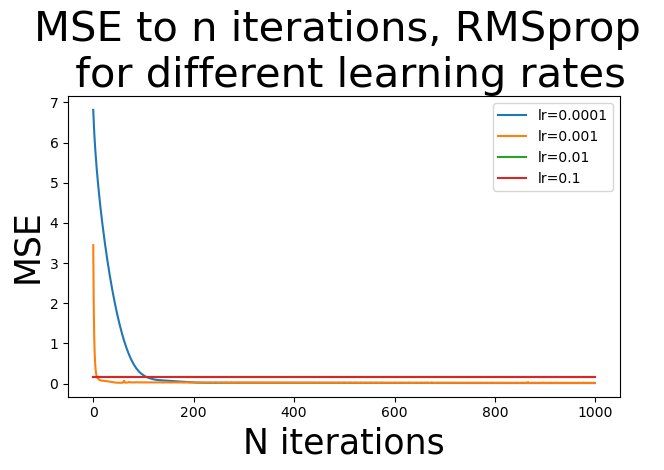

In [23]:
## best model: RMSprop
#lr=0.0001     train MSE=0.017201  test MSE=0.017416

title_text = 'MSE to n iterations, RMSprop \n for different learning rates'
plot_MSE_to_Iter(title_text,histories_best)